# 📈 Stock Analysis Agent — LangGraph Demonstration

This notebook demonstrates a **from-scratch LangGraph agent** that:

1. Accepts a stock ticker symbol
2. Fetches 60 days of historical price data via `yfinance`
3. Calculates technical indicators: **10-day SMA**, **20-day SMA**, **14-day RSI**
4. Produces a rule-based **BUY / HOLD / SELL** recommendation
5. Renders a formatted analysis report
6. Handles errors gracefully (invalid tickers, network issues, insufficient data)

The agent's graph structure, node implementations, and recommendation logic
all live in the `stock_agent/` package next to this notebook — this notebook
just *drives* and *visualizes* that package.

> **Note on data source:** This notebook always attempts to fetch real data
> from Yahoo Finance via `yfinance` first. If you're running it in an
> environment without outbound internet access, the agent will transparently
> fall back to a seeded synthetic price series so you can still see the full
> pipeline run end-to-end — any such report is clearly labeled
> `SYNTHETIC DEMO DATA`. In a normal environment with internet access, you'll
> see real market data.

## 1. Setup

In [1]:
# If running standalone, install dependencies:
# %pip install -r ../requirements.txt

import sys
sys.path.insert(0, "..")  # make the local stock_agent package importable

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from stock_agent import analyze_stock, build_graph

print("stock_agent package loaded successfully.")

stock_agent package loaded successfully.


## 2. Agent Architecture

The agent is built as a `LangGraph` `StateGraph`. Every node reads and writes
a shared `AgentState` dict. Nodes that can fail (`validate_ticker`,
`fetch_data`, `calculate_indicators`) each have a conditional edge that
routes to a dedicated `handle_error` node on failure, so the graph always
terminates cleanly with a `report` string — success or failure.

In [2]:
graph = build_graph()

# Render the graph structure as a Mermaid diagram (text form; renders as a
# diagram automatically on platforms like GitHub, VS Code, or JupyterLab
# with mermaid support installed).
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate_ticker(validate_ticker)
	fetch_data(fetch_data)
	calculate_indicators(calculate_indicators)
	generate_recommendation(generate_recommendation)
	build_report(build_report)
	handle_error(handle_error)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate_ticker;
	calculate_indicators -.-> generate_recommendation;
	calculate_indicators -.-> handle_error;
	fetch_data -.-> calculate_indicators;
	fetch_data -.-> handle_error;
	generate_recommendation --> build_report;
	validate_ticker -.-> fetch_data;
	validate_ticker -.-> handle_error;
	build_report --> __end__;
	handle_error --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
# Optional: render the graph as an actual image (requires internet access
# to the Mermaid.ink rendering service). Falls back gracefully if offline.
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Skipping PNG render — no internet access to the diagram service: {e})")
    print("The Mermaid text diagram above fully describes the graph structure.")

(Skipping PNG render — no internet access to the diagram service: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 403.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`)
The Mermaid text diagram above fully describes the graph structure.


## 3. Basic Usage: Analyze a Single Stock

The `analyze_stock()` convenience function builds the graph, runs it once
with the given ticker, and returns the final state. The final state always
contains a `"report"` key, ready to print.

In [4]:
result = analyze_stock("AAPL")
print(result["report"])

  STOCK ANALYSIS REPORT — AAPL (SYNTHETIC DEMO DATA) (AAPL)
  As of: 2026-08-14
  Data points analyzed: 44 trading days

  PRICE & INDICATORS
  ----------------------------------------
  Close Price:          USD 362.73
  10-Day SMA:           USD 358.32
  20-Day SMA:           USD 354.93
  14-Day RSI:           54.95

  RECOMMENDATION
  ----------------------------------------
  🟢  BUY

  RATIONALE
  ----------------------------------------
  • Bullish trend: 10-day SMA ($358.32) is above the 20-day SMA ($354.93), a 0.95% gap, indicating short-term momentum is stronger than the medium-term trend.
  • Neutral momentum: RSI(14) = 55.0, within the normal 30-70 range.
  • Combined signal score: +2 -> BUY

  RECENT PRICE HISTORY (last 10 trading days)
  ----------------------------------------
  Date             Close     SMA10     SMA20    RSI14
  2026-08-03      354.87    351.02    357.97    47.32
  2026-08-04      357.34    350.68    357.24    49.48
  2026-08-05      355.15    351.10   

### Inspecting the full agent state

Beyond the printed report, the final state carries every intermediate
artifact the graph produced — useful for programmatic access (e.g. feeding
the recommendation into another system) rather than just the text report.

In [5]:
print("Recommendation:", result["recommendation"])
print("Signal score details:", result["signal_details"])
print()
print("Reasons:")
for reason in result["recommendation_reasons"]:
    print(" -", reason)

Recommendation: BUY
Signal score details: {'date': '2026-08-14', 'close': 362.7252451270019, 'sma_10': 358.3158457988008, 'sma_20': 354.9333519204955, 'rsi_14': 54.95170099904059}

Reasons:
 - Bullish trend: 10-day SMA ($358.32) is above the 20-day SMA ($354.93), a 0.95% gap, indicating short-term momentum is stronger than the medium-term trend.
 - Neutral momentum: RSI(14) = 55.0, within the normal 30-70 range.
 - Combined signal score: +2 -> BUY


## 4. Visualizing the Technical Indicators

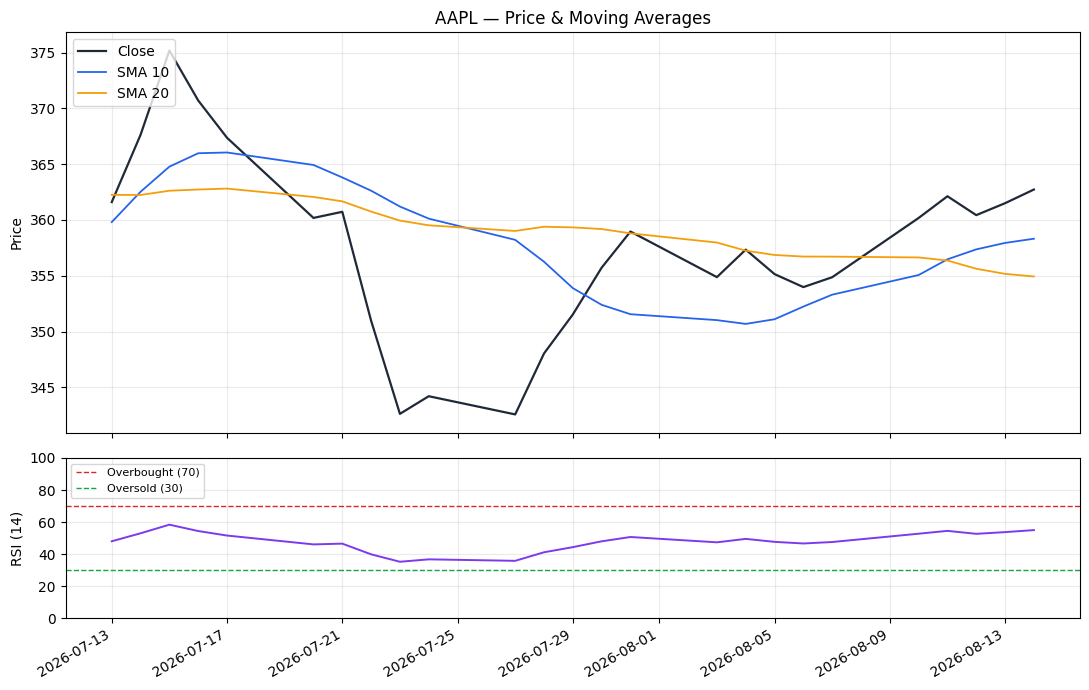

In [6]:
def plot_indicators(state, title=None):
    df = state["indicators"].dropna(subset=["SMA_10", "SMA_20"])
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
    )

    ax1.plot(df.index, df["Close"], label="Close", color="#1f2937", linewidth=1.6)
    ax1.plot(df.index, df["SMA_10"], label="SMA 10", color="#2563eb", linewidth=1.3)
    ax1.plot(df.index, df["SMA_20"], label="SMA 20", color="#f59e0b", linewidth=1.3)
    ax1.set_ylabel("Price")
    ax1.legend(loc="upper left")
    ax1.set_title(title or f"{state['normalized_ticker']} — Price & Moving Averages")
    ax1.grid(alpha=0.25)

    ax2.plot(df.index, df["RSI_14"], color="#7c3aed", linewidth=1.4)
    ax2.axhline(70, color="#dc2626", linestyle="--", linewidth=1, label="Overbought (70)")
    ax2.axhline(30, color="#16a34a", linestyle="--", linewidth=1, label="Oversold (30)")
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("RSI (14)")
    ax2.legend(loc="upper left", fontsize=8)
    ax2.grid(alpha=0.25)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

plot_indicators(result)

## 5. Analyzing Multiple Tickers

Because `analyze_stock()` builds a fresh graph invocation each time, it's
trivial to loop over several tickers and compare recommendations
side-by-side.

In [7]:
tickers = ["AAPL", "MSFT", "GOOGL", "TSLA", "AMZN"]
summary_rows = []

for ticker in tickers:
    res = analyze_stock(ticker)
    if res.get("error"):
        summary_rows.append({"Ticker": ticker, "Recommendation": "ERROR", "Detail": res["error"]})
    else:
        sd = res["signal_details"]
        summary_rows.append({
            "Ticker": ticker,
            "Close": round(sd["close"], 2),
            "SMA10": round(sd["sma_10"], 2),
            "SMA20": round(sd["sma_20"], 2),
            "RSI14": round(sd["rsi_14"], 2),
            "Recommendation": res["recommendation"],
        })

summary_df = pd.DataFrame(summary_rows).set_index("Ticker")
summary_df

,Close,SMA10,SMA20,RSI14,Recommendation
Ticker,,,,,
AAPL,362.73,358.32,354.93,54.95,BUY
MSFT,347.02,351.28,338.71,52.81,BUY
GOOGL,243.25,253.86,252.92,42.45,BUY
TSLA,271.26,272.99,270.82,51.40,BUY
AMZN,355.19,368.49,361.17,49.90,BUY


In [8]:
# Color-code the recommendation column for a quick visual scan
def _highlight(val):
    colors = {"BUY": "background-color: #d1fae5", "SELL": "background-color: #fee2e2", "HOLD": "background-color: #fef9c3"}
    return colors.get(val, "")

summary_df.style.map(_highlight, subset=["Recommendation"])

,Close,SMA10,SMA20,RSI14,Recommendation
Ticker,,,,,
AAPL,362.730000,358.320000,354.930000,54.950000,BUY
MSFT,347.020000,351.280000,338.710000,52.810000,BUY
GOOGL,243.250000,253.860000,252.920000,42.450000,BUY
TSLA,271.260000,272.990000,270.820000,51.400000,BUY
AMZN,355.190000,368.490000,361.170000,49.900000,BUY


## 6. Error Handling Demonstration

The agent is designed to fail gracefully at every stage. Below we
deliberately trigger each failure mode to show that the graph always
terminates with a clean, informative report instead of raising an
exception.

In [9]:
# 6a. Invalid ticker format (caught locally, no network call made)
bad_ticker_result = analyze_stock("NOT-A-REAL-TICKER-12345")
print(bad_ticker_result["report"])
print()
print("Error stage:", bad_ticker_result["error_stage"])

  STOCK ANALYSIS FAILED
  Stage:   validate_ticker
  Reason:  'NOT-A-REAL-TICKER-12345' does not look like a valid ticker symbol (expected 1-10 letters/digits, e.g. 'AAPL', 'BRK-B').

Error stage: validate_ticker


In [10]:
# 6b. Empty input
empty_result = analyze_stock("")
print(empty_result["report"])

  STOCK ANALYSIS FAILED
  Stage:   validate_ticker
  Reason:  No ticker symbol was provided. Please supply a stock ticker, e.g. 'AAPL'.


In [11]:
# 6c. Simulating a network/API failure at the fetch stage.
# We temporarily disable the demo fallback so a real fetch failure
# propagates all the way to the handle_error node, exactly as it would
# on a genuine outage (e.g. Yahoo Finance is unreachable).
import stock_agent.nodes as nodes

original_setting = nodes._ALLOW_SYNTHETIC_FALLBACK
nodes._ALLOW_SYNTHETIC_FALLBACK = False

try:
    from stock_agent.graph import analyze_stock as analyze_stock_fresh
    network_fail_result = analyze_stock_fresh("AAPL")
    print(network_fail_result["report"])
finally:
    nodes._ALLOW_SYNTHETIC_FALLBACK = original_setting  # restore normal behavior

  STOCK ANALYSIS FAILED
  Stage:   fetch_data
  Reason:  No historical data returned for 'AAPL'. It may be an invalid or delisted ticker.


In all three cases above, the graph terminated cleanly through the
`handle_error` node — no unhandled exception propagated to the caller, and
every result still contains a usable `report` string.

## 7. Advanced: Invoking the Graph Directly

For more control (e.g. streaming intermediate steps, adding checkpointing,
or integrating into a larger LangGraph application), you can build and
invoke the graph directly instead of using the `analyze_stock()` wrapper.

In [12]:
graph = build_graph()

# .stream() lets us watch each node fire in sequence
print("Streaming node-by-node execution for ticker 'MSFT':\n")
for step in graph.stream({"ticker": "MSFT"}):
    node_name = list(step.keys())[0]
    print(f"  -> node completed: {node_name}")

final_state = graph.invoke({"ticker": "MSFT"})
print("\nFinal recommendation:", final_state["recommendation"])

Streaming node-by-node execution for ticker 'MSFT':

  -> node completed: validate_ticker
  -> node completed: fetch_data
  -> node completed: calculate_indicators
  -> node completed: generate_recommendation
  -> node completed: build_report

Final recommendation: BUY


## 8. Running the Test Suite

The indicator math and recommendation scoring logic are covered by unit
tests in `tests/test_indicators_and_recommendation.py`, independent of
LangGraph or any network access.

In [13]:
import subprocess
result = subprocess.run(
    ["python3", "-m", "pytest", "../tests/", "-v"],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr[-2000:])

============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.1.1, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/claude/stock_analysis_agent
plugins: anyio-4.14.2, langsmith-0.11.0
collecting ... collected 15 items

../tests/test_indicators_and_recommendation.py::test_sma_basic_average PASSED [  6%]
../tests/test_indicators_and_recommendation.py::test_sma_constant_price PASSED [ 13%]
../tests/test_indicators_and_recommendation.py::test_rsi_all_gains_approaches_100 PASSED [ 20%]
../tests/test_indicators_and_recommendation.py::test_rsi_all_losses_approaches_0 PASSED [ 26%]
../tests/test_indicators_and_recommendation.py::test_rsi_flat_price_is_50 PASSED [ 33%]
../tests/test_indicators_and_recommendation.py::test_rsi_bounds PASSED   [ 40%]
../tests/test_indicators_and_recommendation.py::test_add_all_indicators_columns_present PASSED [ 46%]
../tests/test_indicators_and_recommendation.py::test_add_all_indi

## 9. Try It Yourself

Change the ticker below and re-run the cell.

  STOCK ANALYSIS REPORT — NVDA (SYNTHETIC DEMO DATA) (NVDA)
  As of: 2026-08-14
  Data points analyzed: 44 trading days

  PRICE & INDICATORS
  ----------------------------------------
  Close Price:          USD 149.74
  10-Day SMA:           USD 159.36
  20-Day SMA:           USD 165.25
  14-Day RSI:           31.23

  RECOMMENDATION
  ----------------------------------------
  🔴  SELL

  RATIONALE
  ----------------------------------------
  • Bearish trend: 10-day SMA ($159.36) is below the 20-day SMA ($165.25), a 3.57% gap, indicating short-term momentum is weaker than the medium-term trend.
  • Neutral momentum: RSI(14) = 31.2, within the normal 30-70 range.
  • Combined signal score: -2 -> SELL

  RECENT PRICE HISTORY (last 10 trading days)
  ----------------------------------------
  Date             Close     SMA10     SMA20    RSI14
  2026-08-03      161.83    170.62    165.31    43.91
  2026-08-04      162.51    169.85    165.45    44.88
  2026-08-05      162.47    169.34   

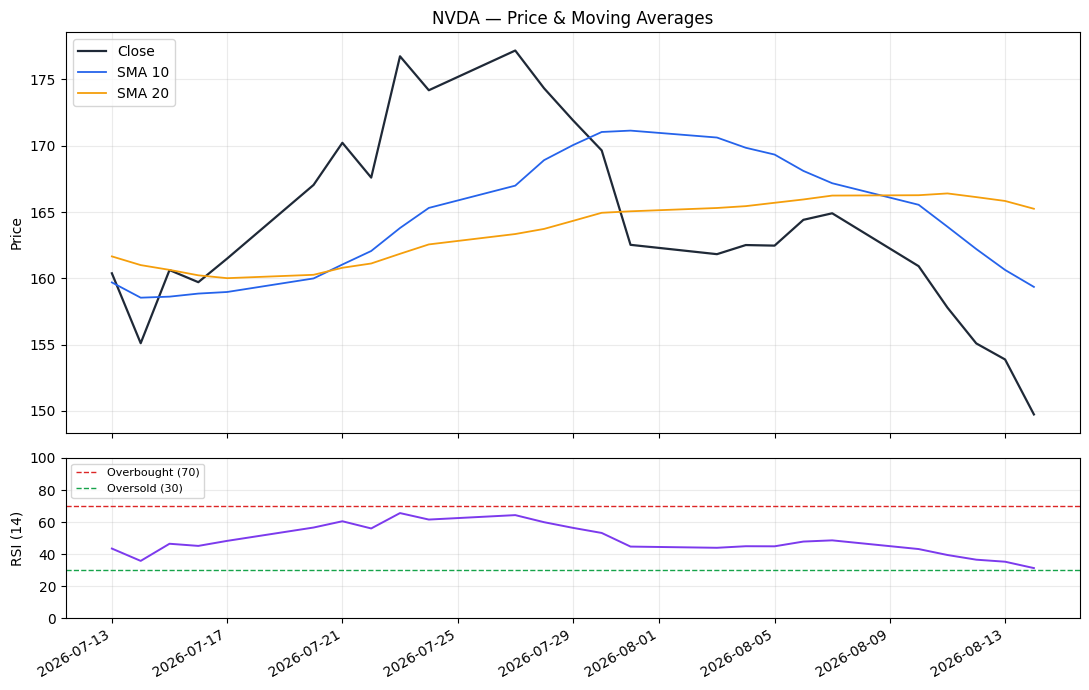

In [14]:
# Change this to any ticker you'd like to analyze
YOUR_TICKER = "NVDA"

my_result = analyze_stock(YOUR_TICKER)
print(my_result["report"])

if not my_result.get("error"):
    plot_indicators(my_result)

## Disclaimer

This notebook and the underlying agent are for **educational purposes
only** and do not constitute financial advice. The recommendation logic
uses simple, well-known technical indicators (SMA crossover, RSI) that have
known limitations — they lag price action, can generate false signals in
choppy or low-volume markets, and ignore fundamentals, news, and
macroeconomic conditions entirely. Always do your own research and consult
a licensed financial advisor before making investment decisions.